Khởi tạo thư viện

In [2]:
import numpy as np
import tensorflow as tf
from keras.models import Sequential

from keras.layers import Dense, Input

from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
import matplotlib.pyplot as plt
train_dir = '/content/drive/MyDrive/60'

In [17]:
img_width, img_height = 128,128
batch_size = 32
train_datagen = ImageDataGenerator(rescale = 1./255, rotation_range = 30, width_shift_range=0.2, height_shift_range= 0.2,
                                   shear_range = 0.2 , zoom_range = 0.2 , horizontal_flip = True,
                                   fill_mode = 'constant', cval=0.0)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(img_width,img_height),
                                                    batch_size = batch_size , class_mode = 'categorical')

Found 1288 images belonging to 30 classes.


In [19]:
model = Sequential([
 Conv2D(32, (3, 3), input_shape=(img_width, img_height, 3), activation='relu'),
 MaxPooling2D(pool_size=(2, 2)),
 Conv2D(64, (3, 3), activation='relu'),
 MaxPooling2D((2,2)),
 Conv2D(128, (3, 3), activation='relu'),
 MaxPooling2D((2,2)),

 Flatten(),
 Dense(128, activation = 'relu'),
 Dropout(0.5),
 Dense(30, activation = 'softmax')
  ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         3,870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,308,510 (12.62 MB)

 Trainable params: 3,308,510 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 114s 3s/step - accuracy: 0.5202 - loss: 1.6043
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.5536 - loss: 1.4642
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - accuracy: 0.5536 - loss: 1.4581
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - accuracy: 0.5707 - loss: 1.4123
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.5862 - loss: 1.3850
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.5963 - loss: 1.3123
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - accuracy: 0.5955 - loss: 1.3530
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - accuracy: 0.5800 - loss: 1.3395
Epoch 9/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.5939 - loss: 1.3116
Epoch 10/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.6071 - loss: 1.3338
Epoch 11/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - accuracy: 0.6180 - loss: 1.2485
Epoch 12/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy:

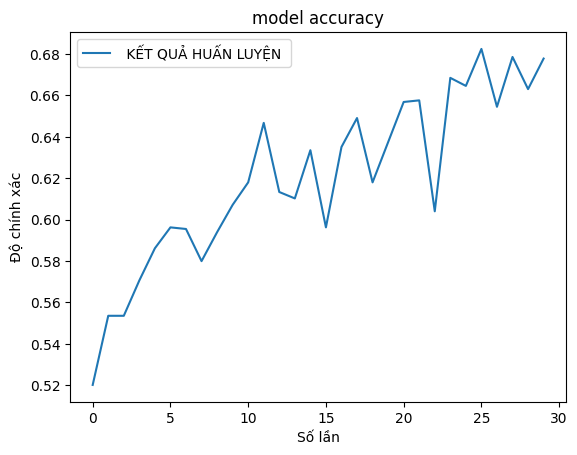

In [9]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
history = model.fit(train_generator,epochs = 30)
plt.plot(history.history['accuracy'], label = ' KẾT QUẢ HUẤN LUYỆN ')
plt.title('model accuracy')
plt.ylabel('Độ chính xác')
plt.xlabel('Số lần')
plt.legend()
plt.show()

In [13]:
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/best_model.keras',
    save_best_only=True,
    monitor='accuracy'
)

In [27]:
model.save('/content/drive/MyDrive/best_model.keras')